--- Dataset Overview ---
           Region         Date Frequency  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019   Monthly                             3.65   
1  Andhra Pradesh   30-06-2019   Monthly                             3.05   
2  Andhra Pradesh   31-07-2019   Monthly                             3.75   
3  Andhra Pradesh   31-08-2019   Monthly                             3.32   
4  Andhra Pradesh   30-09-2019   Monthly                             5.17   

   Estimated Employed  Estimated Labour Participation Rate (%)   Area  
0          11999139.0                                    43.24  Rural  
1          11755881.0                                    42.05  Rural  
2          12086707.0                                    43.50  Rural  
3          12285693.0                                    43.97  Rural  
4          12256762.0                                    44.68  Rural  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data col

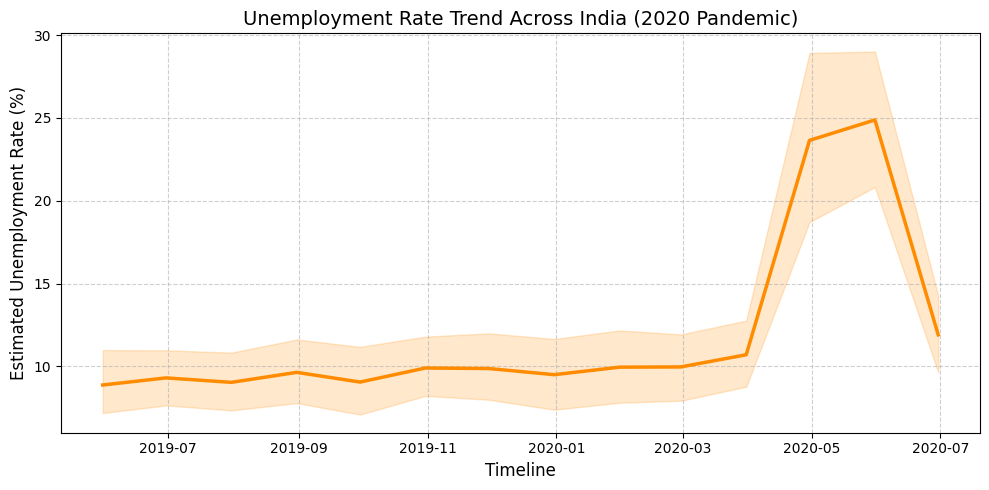

/tmp/ipykernel_21238/2305119788.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_unemployment, x='Estimated Unemployment Rate (%)', y='Region', palette='viridis')


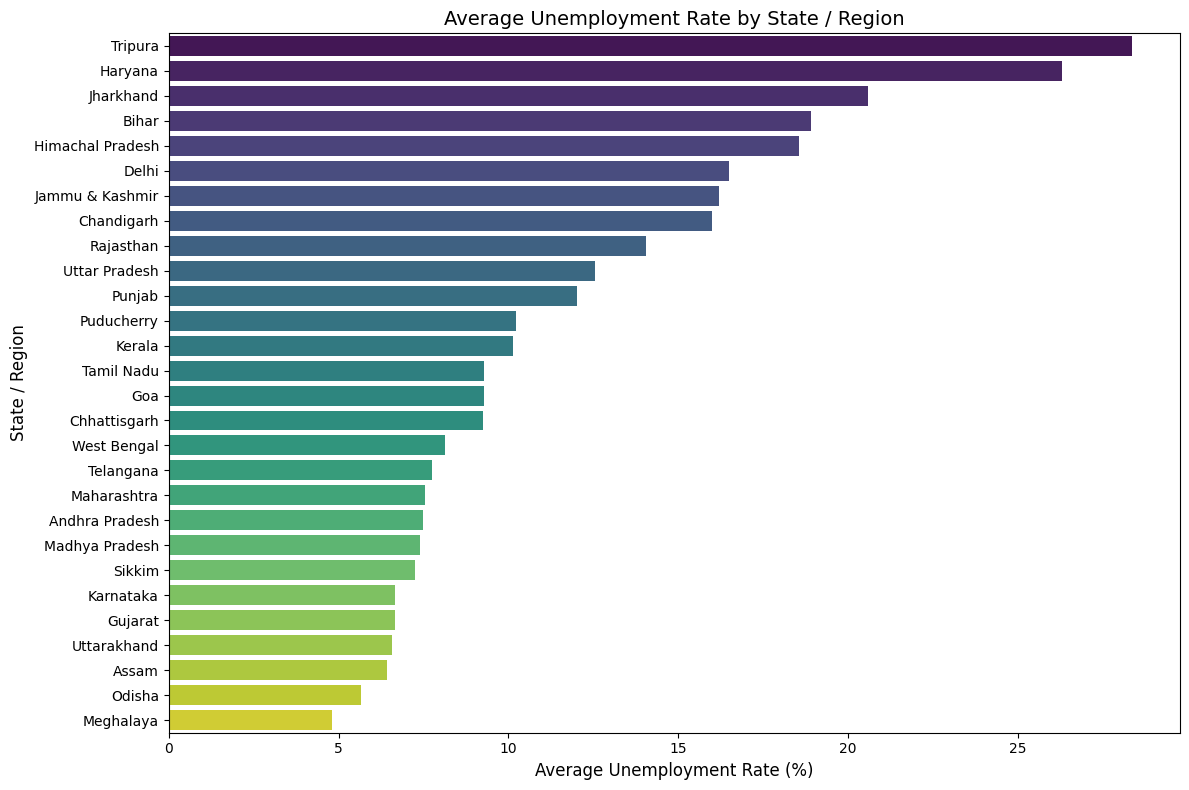

/tmp/ipykernel_21238/2305119788.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Area', y='Estimated Unemployment Rate (%)', palette='Set2')


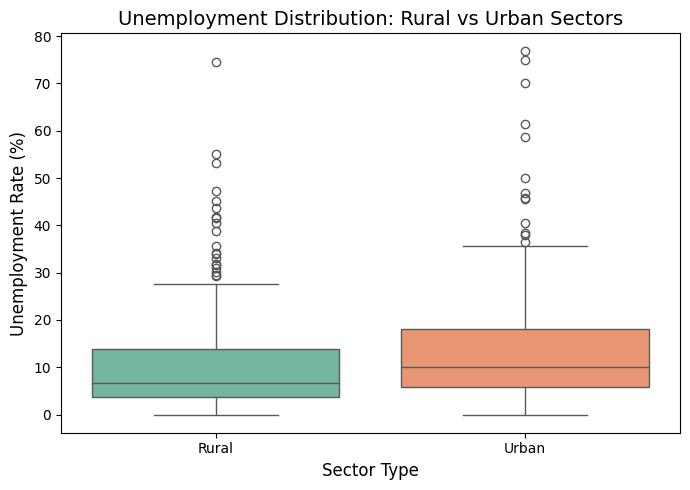

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Ensures interactive plots display inside your Linux Jupyter environment
%matplotlib inline
# 1. Load the Dataset 
# Note: Check your exact file name. It might be 'Unemployment in India.csv'
try:
    df = pd.read_csv('/home/wlug/Downloads/archive(3)/Unemployment in India.csv')
except FileNotFoundError:
    df = pd.read_csv('Unemployment in India.csv')
# Clean up column spaces (The source dataset often has leading/trailing spaces in headers)
df.columns = df.columns.str.strip()
print("--- Dataset Overview ---")
print(df.head())
print(df.info())
# 2. Data Preprocessing & Cleaning
# Convert the Date column into a properdatetime object for seasonal grouping
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Month'] = df['Date'].dt.strftime('%B')
# 3. Data Visualization 1: Overall Timeline Trend
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='Date', y='Estimated Unemployment Rate (%)', color='darkorange', lw=2.5)
plt.title('Unemployment Rate Trend Across India (2020 Pandemic)', fontsize=14)
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Estimated Unemployment Rate (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
# 4. Data Visualization 2: State-wise Breakdown Impact
plt.figure(figsize=(12, 8))
state_unemployment = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=state_unemployment, x='Estimated Unemployment Rate (%)', y='Region', palette='viridis')
plt.title('Average Unemployment Rate by State / Region', fontsize=14)
plt.xlabel('Average Unemployment Rate (%)', fontsize=12)
plt.ylabel('State / Region', fontsize=12)
plt.tight_layout()
plt.show()
# 5. Data Visualization 3: Regional Category Analysis (Rural vs Urban)
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='Area', y='Estimated Unemployment Rate (%)', palette='Set2')
plt.title('Unemployment Distribution: Rural vs Urban Sectors', fontsize=14)
plt.xlabel('Sector Type', fontsize=12)
plt.ylabel('Unemployment Rate (%)', fontsize=12)
plt.tight_layout()
plt.show()